# DRO Forecasting Notebook

This notebook implements the robust forecasting layer of the thesis pipeline.

Up to this point:

- `01_var_mechanics` established the classical VAR forecasting benchmark
- `02_bvar_mechanics` added Bayesian VAR inference and predictive forecasting
- `03_innovation_modeling` diagnosed the innovation distribution and compared baseline shock models
- `04_diffusion_residual_generator` trained a learned generative model for innovations

The goal of this notebook is to combine these ingredients with **distributional robustness**.

## Motivation

Standard forecasting procedures typically assume that the innovation law used at forecast time is correctly specified. In practice, however, even after fitting a VAR or BVAR and even after learning a more flexible innovation generator, there remains uncertainty about the true forecast-time shock distribution.

Rather than committing to a single innovation law, we now consider a **family of plausible shock distributions** around a reference model.

Formally, if $P_0$ is a reference innovation distribution, we construct an ambiguity set

$$
\mathcal{P}_\varepsilon
=
\{Q : W(Q, P_0) \le \varepsilon\},
$$

where $W(\cdot,\cdot)$ is a Wasserstein distance and $\varepsilon \ge 0$ controls the size of the uncertainty region.

The forecasting problem is then no longer just:

$$
\mathbb{E}_{P_0}[L(Y_{t+h})],
$$

but instead the robust version

$$
\sup_{Q \in \mathcal{P}_\varepsilon} \mathbb{E}_Q[L(Y_{t+h})].
$$

This notebook studies how forecast summaries change when we account for distributional ambiguity in this way.

## Main goals

This notebook will:

1. reconstruct a benchmark forecasting model
2. define reference shock laws for forecast simulation
3. construct Wasserstein-style ambiguity sets around those laws
4. compute robust forecast summaries under worst-case perturbations
5. compare:
   - standard Gaussian forecasts
   - bootstrap forecasts
   - diffusion-based forecasts
   - robustified forecast variants
6. evaluate how robustness changes:
   - forecast means
   - predictive intervals
   - downside/tail risk summaries
   - stress-test behavior

## Initial strategy

To keep the first implementation transparent, we begin with a simulation-based DRO layer:

- use a fitted benchmark VAR/BVAR system
- choose a reference innovation generator
- perturb forecast shocks adversarially within a Wasserstein-style budget
- study the effect on forecast distributions and loss summaries

We begin by importing packages and setting up a reproducible environment for robust forecast construction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import pickle

from pathlib import Path
from datetime import datetime

from scipy.stats import multivariate_normal, skew, kurtosis

# -----------------------------------------------------------------------------
# Global reproducibility
# -----------------------------------------------------------------------------
GLOBAL_SEED = 123
rng = np.random.default_rng(GLOBAL_SEED)

print("=" * 80)
print("DRO FORECASTING NOTEBOOK SETUP")
print("=" * 80)
print(f"Global seed: {GLOBAL_SEED}")
print()

# -----------------------------------------------------------------------------
# Plot settings
# -----------------------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Imports loaded successfully.")
print("Ready to reconstruct the benchmark model and build robust forecasts.")

DRO FORECASTING NOTEBOOK SETUP
Global seed: 123

Imports loaded successfully.
Ready to reconstruct the benchmark model and build robust forecasts.


## Recreate the Benchmark VAR System and Forecasting Objects

To make this notebook self-contained, we recreate the same simulated benchmark VAR system used in the earlier notebooks.

This gives us:

1. a known stable multivariate data-generating process
2. a fitted benchmark forecasting model
3. a forecast origin and recent history
4. a clean environment for comparing standard and robust forecasts

We begin with the OLS VAR benchmark because it is the most transparent setting for introducing the DRO layer. Later, the same robust forecasting logic can be attached to BVAR forecasts and diffusion-based shock generators.

The benchmark model is

$$
y_t = c + A_1 y_{t-1} + \dots + A_p y_{t-p} + u_t.
$$

Once fitted, this notebook will treat the system dynamics $(c, A_1, \dots, A_p)$ as fixed and focus on robustness with respect to the innovation law used during forecast simulation.

In [2]:
# -----------------------------------------------------------------------------
# Core VAR helpers
# -----------------------------------------------------------------------------
def companion_matrix(A_list):
    p = len(A_list)
    k = A_list[0].shape[0]

    top_block = np.hstack(A_list)

    if p == 1:
        return top_block

    lower_block = np.hstack([
        np.eye(k * (p - 1)),
        np.zeros((k * (p - 1), k))
    ])

    return np.vstack([top_block, lower_block])


def is_var_stable(A_list, tol=0.999):
    F = companion_matrix(A_list)
    eigvals = np.linalg.eigvals(F)
    max_modulus = np.max(np.abs(eigvals))
    return max_modulus < tol, max_modulus, eigvals


def simulate_var(A_list, Sigma, T, burnin=200, seed=123, return_shocks=False):
    local_rng = np.random.default_rng(seed)

    p_local = len(A_list)
    k_local = A_list[0].shape[0]
    total_T = T + burnin

    Y = np.zeros((total_T + p_local, k_local))
    shocks = local_rng.multivariate_normal(
        mean=np.zeros(k_local),
        cov=Sigma,
        size=total_T
    )

    for t in range(p_local, total_T + p_local):
        y_t = np.zeros(k_local)

        for lag in range(1, p_local + 1):
            y_t += A_list[lag - 1] @ Y[t - lag]

        y_t += shocks[t - p_local]
        Y[t] = y_t

    Y_retained = Y[p_local + burnin:]
    shocks_retained = shocks[burnin:]

    if return_shocks:
        return Y_retained, shocks_retained
    return Y_retained


def build_var_regression_matrices(Y, p, include_intercept=True):
    Y = np.asarray(Y)
    T, k_local = Y.shape

    if T <= p:
        raise ValueError(f"Need T > p, but got T={T}, p={p}")

    X_rows = []
    Y_rows = []
    feature_names = []

    if include_intercept:
        feature_names.append("const")

    for lag in range(1, p + 1):
        for j in range(k_local):
            feature_names.append(f"y{j+1}_lag{lag}")

    for t in range(p, T):
        row = []

        if include_intercept:
            row.append(1.0)

        for lag in range(1, p + 1):
            row.extend(Y[t - lag, :])

        X_rows.append(row)
        Y_rows.append(Y[t, :])

    X = np.array(X_rows)
    Y_target = np.array(Y_rows)

    return Y_target, X, feature_names


def extract_var_coefficients(B, k, p, include_intercept=True):
    row_idx = 0
    intercept = None

    if include_intercept:
        intercept = B[0, :]
        row_idx = 1

    A_list = []
    for lag in range(p):
        block = B[row_idx + lag * k : row_idx + (lag + 1) * k, :]
        A_list.append(block.T)

    return intercept, A_list


def fit_var_ols(Y, p, include_intercept=True):
    Y_target, X, feature_names = build_var_regression_matrices(
        Y=Y,
        p=p,
        include_intercept=include_intercept
    )

    XtX = X.T @ X
    XtY = X.T @ Y_target
    B_hat = np.linalg.solve(XtX, XtY)

    fitted_values = X @ B_hat
    residuals = Y_target - fitted_values

    T_eff, k_local = Y_target.shape
    Sigma_hat = (residuals.T @ residuals) / T_eff

    intercept_hat, A_hat_list = extract_var_coefficients(
        B_hat,
        k=k_local,
        p=p,
        include_intercept=include_intercept
    )

    return {
        "B_hat": B_hat,
        "residuals": residuals,
        "Sigma_hat": Sigma_hat,
        "Y_target": Y_target,
        "X": X,
        "feature_names": feature_names,
        "intercept": intercept_hat,
        "A_hat_list": A_hat_list,
        "fitted_values": fitted_values,
    }


def var_forecast(A_list, intercept, y_history, h):
    """
    Deterministic h-step VAR forecast path using zero shocks.
    y_history should have shape (p, k), ordered oldest -> newest.
    """
    y_history = np.asarray(y_history)
    p_local = len(A_list)
    k_local = A_list[0].shape[0]

    history = [y_history[i].copy() for i in range(p_local)]
    forecasts = []

    for _ in range(h):
        y_next = intercept.copy() if intercept is not None else np.zeros(k_local)

        for lag in range(1, p_local + 1):
            y_next += A_list[lag - 1] @ history[-lag]

        forecasts.append(y_next.copy())
        history.append(y_next.copy())

    return np.array(forecasts)


# -----------------------------------------------------------------------------
# Recreate benchmark data
# -----------------------------------------------------------------------------
k = 3
p = 2
T = 300

A1 = np.array([
    [0.50, 0.10, 0.00],
    [0.05, 0.40, 0.10],
    [0.00, 0.10, 0.35]
])

A2 = np.array([
    [-0.20, 0.00, 0.05],
    [0.00, -0.15, 0.00],
    [0.05, 0.00, -0.10]
])

Sigma = np.array([
    [1.00, 0.30, 0.20],
    [0.30, 0.80, 0.25],
    [0.20, 0.25, 0.60]
])

stable, max_modulus, eigvals = is_var_stable([A1, A2])

print("=" * 80)
print("RECREATED BENCHMARK VAR SYSTEM")
print("=" * 80)
print(f"Stable VAR: {stable}")
print(f"Max eigenvalue modulus: {max_modulus:.4f}")

if not stable:
    raise ValueError("Chosen benchmark DGP is not stable.")

Y, true_shocks = simulate_var(
    [A1, A2],
    Sigma,
    T=T,
    burnin=300,
    seed=GLOBAL_SEED,
    return_shocks=True
)

columns = [f"y{i+1}" for i in range(k)]
df = pd.DataFrame(Y, columns=columns)
df.index.name = "time"

# -----------------------------------------------------------------------------
# Fit benchmark OLS VAR
# -----------------------------------------------------------------------------
var_fit = fit_var_ols(df.values, p=p, include_intercept=True)

residuals_df = pd.DataFrame(
    var_fit["residuals"],
    columns=[f"u_hat{i+1}" for i in range(k)],
    index=df.index[p:]
)
residuals_df.index.name = "time"

print()
print("Fitted benchmark VAR")
print("-" * 80)
print(f"Residual matrix shape: {residuals_df.shape}")
print("Estimated intercept:")
print(np.round(var_fit["intercept"], 4))
print()

for lag, A_hat in enumerate(var_fit["A_hat_list"], start=1):
    print(f"Estimated A{lag}:")
    print(np.round(A_hat, 4))
    print()

print("Estimated innovation covariance:")
display(pd.DataFrame(
    var_fit["Sigma_hat"],
    index=residuals_df.columns,
    columns=residuals_df.columns
).round(4))

# -----------------------------------------------------------------------------
# Define forecast origin
# -----------------------------------------------------------------------------
h_forecast = 10
y_history = df.values[-p:, :]

deterministic_forecast = var_forecast(
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    h=h_forecast
)

deterministic_forecast_df = pd.DataFrame(
    deterministic_forecast,
    columns=columns,
    index=np.arange(1, h_forecast + 1)
)

print("=" * 80)
print("FORECAST ORIGIN SET")
print("=" * 80)
print(f"Forecast horizon: {h_forecast}")
print("Recent history used as forecast origin:")
display(pd.DataFrame(y_history, columns=columns, index=[f"lag_{p-1}", f"lag_{p}"]))

print("Deterministic zero-shock forecast path:")
display(deterministic_forecast_df.round(4))

RECREATED BENCHMARK VAR SYSTEM
Stable VAR: True
Max eigenvalue modulus: 0.4650

Fitted benchmark VAR
--------------------------------------------------------------------------------
Residual matrix shape: (298, 3)
Estimated intercept:
[ 0.1056 -0.0068  0.0034]

Estimated A1:
[[0.39   0.102  0.0727]
 [0.0932 0.2965 0.0581]
 [0.0215 0.101  0.3027]]

Estimated A2:
[[-0.2265 -0.0332  0.1451]
 [ 0.0195 -0.0657 -0.0462]
 [ 0.0234 -0.0173 -0.0618]]

Estimated innovation covariance:


,u_hat1,u_hat2,u_hat3
u_hat1,0.9274,0.3144,0.2276
u_hat2,0.3144,0.8313,0.2886
u_hat3,0.2276,0.2886,0.7300


FORECAST ORIGIN SET
Forecast horizon: 10
Recent history used as forecast origin:


,y1,y2,y3
lag_1,1.209753,0.198130,-0.160984
lag_2,1.231485,0.935197,-0.216770


Deterministic zero-shock forecast path:


,y1,y2,y3
1,0.3616,0.3907,0.0936
2,-0.0480,0.1208,0.1051
3,0.0256,0.0077,0.0423
4,0.1416,-0.0135,0.0078
5,0.1601,0.0009,0.0053
6,0.1381,0.0119,0.0116
7,0.1260,0.0131,0.0145
8,0.1272,0.0110,0.0141
9,0.1305,0.0100,0.0134
10,0.1314,0.0102,0.0132


## Define Reference Shock Generators for Standard Forecast Simulation

Before adding robustness, we first define the baseline innovation generators that will drive forecast simulation.

These reference generators correspond to the innovation models studied in the earlier notebooks:

1. **Gaussian shocks**
2. **Bootstrap shocks**
3. **Diffusion shocks** (to be plugged in from saved artifacts or regenerated later)

In this first pass through the DRO notebook, we will immediately implement the Gaussian and bootstrap generators and build a generic simulation engine for forecast paths.

The forecast recursion is

$$
y_{t+h}
=
c + A_1 y_{t+h-1} + \dots + A_p y_{t+h-p} + u_{t+h},
$$

where the shock sequence $(u_{t+1}, \dots, u_{t+h})$ is drawn from a chosen generator.

This gives us a standard Monte Carlo forecast distribution before any robust perturbation is applied.

In [3]:
# -----------------------------------------------------------------------------
# Baseline shock generators
# -----------------------------------------------------------------------------
def generate_gaussian_shock_path(h, Sigma_hat, seed=None):
    """
    Generate an h-step Gaussian shock path with covariance Sigma_hat.
    Returns array of shape (h, k).
    """
    local_rng = np.random.default_rng(seed)
    k_local = Sigma_hat.shape[0]
    return local_rng.multivariate_normal(
        mean=np.zeros(k_local),
        cov=Sigma_hat,
        size=h
    )


def generate_bootstrap_shock_path(h, residuals_array, seed=None):
    """
    Generate an h-step bootstrap shock path by resampling empirical residuals.
    Returns array of shape (h, k).
    """
    local_rng = np.random.default_rng(seed)
    idx = local_rng.choice(len(residuals_array), size=h, replace=True)
    return residuals_array[idx]


# -----------------------------------------------------------------------------
# Forecast simulator given a shock path
# -----------------------------------------------------------------------------
def simulate_var_forecast_with_shocks(A_list, intercept, y_history, shock_path):
    """
    Simulate a forecast path using a supplied shock path.

    Parameters
    ----------
    A_list : list of np.ndarray
        VAR coefficient matrices
    intercept : np.ndarray
        Intercept vector
    y_history : np.ndarray
        Most recent p observations, shape (p, k), ordered oldest -> newest
    shock_path : np.ndarray
        Forecast-period shocks, shape (h, k)

    Returns
    -------
    y_path : np.ndarray
        Simulated forecast path, shape (h, k)
    """
    y_history = np.asarray(y_history)
    shock_path = np.asarray(shock_path)

    p_local = len(A_list)
    k_local = A_list[0].shape[0]
    h_local = shock_path.shape[0]

    history = [y_history[i].copy() for i in range(p_local)]
    forecasts = []

    for t in range(h_local):
        y_next = intercept.copy() if intercept is not None else np.zeros(k_local)

        for lag in range(1, p_local + 1):
            y_next += A_list[lag - 1] @ history[-lag]

        y_next += shock_path[t]
        forecasts.append(y_next.copy())
        history.append(y_next.copy())

    return np.array(forecasts)


# -----------------------------------------------------------------------------
# Monte Carlo forecast draws under a chosen generator
# -----------------------------------------------------------------------------
def simulate_forecast_draws(generator_name, n_draws, h, A_list, intercept, y_history,
                            Sigma_hat=None, residuals_array=None, seed=123):
    """
    Simulate forecast draws under a named shock generator.
    """
    local_rng = np.random.default_rng(seed)
    draws = []

    for s in range(n_draws):
        draw_seed = int(local_rng.integers(0, 10_000_000))

        if generator_name == "gaussian":
            shock_path = generate_gaussian_shock_path(h, Sigma_hat=Sigma_hat, seed=draw_seed)
        elif generator_name == "bootstrap":
            shock_path = generate_bootstrap_shock_path(h, residuals_array=residuals_array, seed=draw_seed)
        else:
            raise ValueError(f"Unknown generator_name: {generator_name}")

        y_path = simulate_var_forecast_with_shocks(
            A_list=A_list,
            intercept=intercept,
            y_history=y_history,
            shock_path=shock_path
        )
        draws.append(y_path)

    return np.array(draws)


# -----------------------------------------------------------------------------
# Generate baseline forecast draws
# -----------------------------------------------------------------------------
n_mc_draws = 1000

gaussian_forecast_draws = simulate_forecast_draws(
    generator_name="gaussian",
    n_draws=n_mc_draws,
    h=h_forecast,
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    Sigma_hat=var_fit["Sigma_hat"],
    seed=GLOBAL_SEED
)

bootstrap_forecast_draws = simulate_forecast_draws(
    generator_name="bootstrap",
    n_draws=n_mc_draws,
    h=h_forecast,
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    residuals_array=residuals_df.values,
    seed=GLOBAL_SEED
)

print("=" * 80)
print("BASELINE FORECAST DRAWS GENERATED")
print("=" * 80)
print(f"Gaussian forecast draws shape:  {gaussian_forecast_draws.shape}")
print(f"Bootstrap forecast draws shape: {bootstrap_forecast_draws.shape}")
print()

print("One Gaussian forecast draw (first 3 horizons):")
display(pd.DataFrame(gaussian_forecast_draws[0][:3], columns=columns, index=np.arange(1, 4)).round(4))

print("One Bootstrap forecast draw (first 3 horizons):")
display(pd.DataFrame(bootstrap_forecast_draws[0][:3], columns=columns, index=np.arange(1, 4)).round(4))

BASELINE FORECAST DRAWS GENERATED
Gaussian forecast draws shape:  (1000, 10, 3)
Bootstrap forecast draws shape: (1000, 10, 3)

One Gaussian forecast draw (first 3 horizons):


,y1,y2,y3
1,-0.2815,0.1393,0.4784
2,-0.0802,-0.1567,0.0815
3,-0.2990,-1.5907,-0.3899


One Bootstrap forecast draw (first 3 horizons):


,y1,y2,y3
1,0.1214,0.3768,0.0832
2,1.6461,0.3083,0.0744
3,0.9416,1.0017,1.5227


## Summarize Standard Forecast Distributions

With Monte Carlo forecast draws in hand, we now summarize the standard forecast distributions before introducing distributional robustness.

For each horizon and variable, we compute:

- forecast mean
- lower predictive bound
- upper predictive bound

using the empirical quantiles of the simulated forecast draws.

These baseline summaries will later be compared against robustified forecast distributions obtained by perturbing the reference innovation law.

STANDARD FORECAST SUMMARIES
Gaussian forecast means:


,y1_gauss_mean,y2_gauss_mean,y3_gauss_mean
1,0.3827,0.3714,0.0938
2,-0.0642,0.1252,0.1634
3,0.0425,0.0506,0.0413
4,0.1988,0.0451,-0.0007
5,0.1109,-0.0132,-0.0019
6,0.0667,-0.0378,-0.0367
7,0.1193,-0.0127,-0.0142
8,0.1004,0.0234,-0.0353
9,0.0897,0.0171,0.0274
10,0.0625,-0.0084,-0.0031


Bootstrap forecast means:


,y1_boot_mean,y2_boot_mean,y3_boot_mean
1,0.3411,0.3876,0.0775
2,-0.0692,0.1577,0.1233
3,-0.0288,-0.0171,0.0607
4,0.1328,-0.0325,0.0270
5,0.1714,-0.0238,-0.0241
6,0.1512,0.0364,-0.0448
7,0.1093,-0.0330,-0.0188
8,0.1235,-0.0319,0.0108
9,0.1231,-0.0133,-0.0097
10,0.1040,-0.0297,0.0177


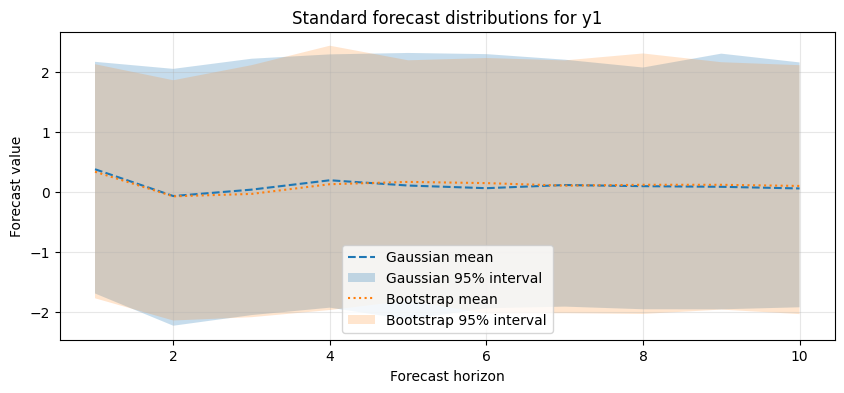

In [4]:
# -----------------------------------------------------------------------------
# Forecast summary helper
# -----------------------------------------------------------------------------
def summarize_forecast_draws(forecast_draws, alpha=0.05):
    """
    Summarize forecast draws of shape (n_draws, h, k).
    """
    mean_fcst = forecast_draws.mean(axis=0)
    lower_fcst = np.quantile(forecast_draws, alpha / 2, axis=0)
    upper_fcst = np.quantile(forecast_draws, 1 - alpha / 2, axis=0)

    return {
        "mean": mean_fcst,
        "lower": lower_fcst,
        "upper": upper_fcst
    }


gaussian_summary = summarize_forecast_draws(gaussian_forecast_draws, alpha=0.05)
bootstrap_summary = summarize_forecast_draws(bootstrap_forecast_draws, alpha=0.05)

print("=" * 80)
print("STANDARD FORECAST SUMMARIES")
print("=" * 80)

gaussian_mean_df = pd.DataFrame(
    gaussian_summary["mean"],
    columns=[f"{c}_gauss_mean" for c in columns],
    index=np.arange(1, h_forecast + 1)
)

bootstrap_mean_df = pd.DataFrame(
    bootstrap_summary["mean"],
    columns=[f"{c}_boot_mean" for c in columns],
    index=np.arange(1, h_forecast + 1)
)

print("Gaussian forecast means:")
display(gaussian_mean_df.round(4))

print("Bootstrap forecast means:")
display(bootstrap_mean_df.round(4))

# -----------------------------------------------------------------------------
# Plot forecast intervals for y1
# -----------------------------------------------------------------------------
future_index = np.arange(1, h_forecast + 1)

plt.figure(figsize=(10, 4))
plt.plot(future_index, gaussian_summary["mean"][:, 0], linestyle="--", label="Gaussian mean")
plt.fill_between(
    future_index,
    gaussian_summary["lower"][:, 0],
    gaussian_summary["upper"][:, 0],
    alpha=0.25,
    label="Gaussian 95% interval"
)

plt.plot(future_index, bootstrap_summary["mean"][:, 0], linestyle=":", label="Bootstrap mean")
plt.fill_between(
    future_index,
    bootstrap_summary["lower"][:, 0],
    bootstrap_summary["upper"][:, 0],
    alpha=0.20,
    label="Bootstrap 95% interval"
)

plt.title("Standard forecast distributions for y1")
plt.xlabel("Forecast horizon")
plt.ylabel("Forecast value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Simulation-Based Robust Forecasting via Adversarial Shock Perturbations

We now introduce a first approximation to distributionally robust forecasting.

Instead of assuming shocks are drawn exactly from a reference distribution $P_0$, we allow them to be perturbed within a budget.

We approximate the ambiguity set

$$
\mathcal{P}_\varepsilon = \{Q : W(Q, P_0) \le \varepsilon\}
$$

by constructing **adversarial shock perturbations**:

$$
u_t^{robust} = u_t + \delta_t
$$

where

$$
\|\delta_t\| \le \varepsilon.
$$

We consider worst-case directions relative to a chosen loss function.

In this first implementation, we focus on **downside risk**:

- pushing forecasts downward
- increasing lower-tail risk
- widening predictive intervals

This produces a tractable and interpretable approximation to the robust forecast:

$$
\sup_{Q \in \mathcal{P}_\varepsilon} \mathbb{E}_Q[L(Y_{t+h})].
$$

We now implement a simple adversarial perturbation scheme applied to forecast shocks.

ROBUST FORECAST (GAUSSIAN BASE)
Epsilon: 0.2



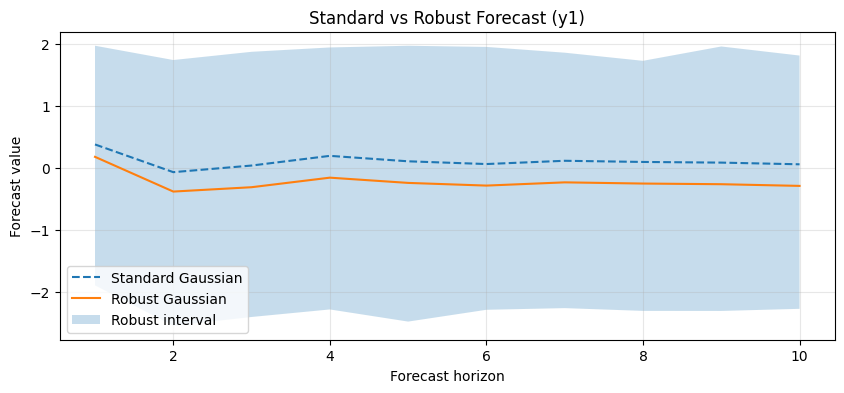

In [17]:
# -----------------------------------------------------------------------------
# Adversarial shock perturbation
# -----------------------------------------------------------------------------
def perturb_shock_path(shock_path, epsilon, direction="down"):
    """
    Apply adversarial perturbation to a shock path.

    Parameters
    ----------
    shock_path : np.ndarray (h, k)
    epsilon : float
        magnitude of perturbation
    direction : str
        "down" (push forecasts downward)
        "up"   (push forecasts upward)

    Returns
    -------
    perturbed shock path
    """
    shock_path = np.asarray(shock_path)
    h, k_local = shock_path.shape

    if direction == "down":
        delta = -epsilon * np.ones((h, k_local))
    elif direction == "up":
        delta = epsilon * np.ones((h, k_local))
    else:
        raise ValueError("direction must be 'down' or 'up'")

    return shock_path + delta


# -----------------------------------------------------------------------------
# Robust forecast simulation
# -----------------------------------------------------------------------------
def simulate_robust_forecast_draws(
    base_generator,
    n_draws,
    h,
    epsilon,
    direction,
    A_list,
    intercept,
    y_history,
    Sigma_hat=None,
    residuals_array=None,
    seed=123
):
    local_rng = np.random.default_rng(seed)
    draws = []

    for s in range(n_draws):
        draw_seed = int(local_rng.integers(0, 10_000_000))

        if base_generator == "gaussian":
            shock_path = generate_gaussian_shock_path(h, Sigma_hat, seed=draw_seed)
        elif base_generator == "bootstrap":
            shock_path = generate_bootstrap_shock_path(h, residuals_array, seed=draw_seed)
        else:
            raise ValueError("unknown base_generator")

        # Apply adversarial perturbation
        shock_path_robust = perturb_shock_path(
            shock_path,
            epsilon=epsilon,
            direction=direction
        )

        y_path = simulate_var_forecast_with_shocks(
            A_list=A_list,
            intercept=intercept,
            y_history=y_history,
            shock_path=shock_path_robust
        )

        draws.append(y_path)

    return np.array(draws)


# -----------------------------------------------------------------------------
# Run robust simulations
# -----------------------------------------------------------------------------
epsilon = 0.2

robust_gaussian_draws = simulate_robust_forecast_draws(
    base_generator="gaussian",
    n_draws=n_mc_draws,
    h=h_forecast,
    epsilon=epsilon,
    direction="down",
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    Sigma_hat=var_fit["Sigma_hat"],
    seed=GLOBAL_SEED
)

robust_gaussian_summary = summarize_forecast_draws(robust_gaussian_draws)

print("=" * 80)
print("ROBUST FORECAST (GAUSSIAN BASE)")
print("=" * 80)
print(f"Epsilon: {epsilon}")
print()

# -----------------------------------------------------------------------------
# Plot comparison
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 4))

plt.plot(future_index, gaussian_summary["mean"][:, 0], label="Standard Gaussian", linestyle="--")
plt.plot(future_index, robust_gaussian_summary["mean"][:, 0], label="Robust Gaussian", linestyle="-")

plt.fill_between(
    future_index,
    robust_gaussian_summary["lower"][:, 0],
    robust_gaussian_summary["upper"][:, 0],
    alpha=0.25,
    label="Robust interval"
)

plt.title("Standard vs Robust Forecast (y1)")
plt.xlabel("Forecast horizon")
plt.ylabel("Forecast value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Add Diffusion-Based Forecast Simulation and Robustification

We now extend the robust forecasting pipeline to the diffusion shock generator.

This is the most important comparison in the notebook because it combines:

- a learned innovation law from `04_diffusion_residual_generator`
- a robustness layer that protects against misspecification around that learned law

The logic is:

1. generate shock paths from the diffusion model
2. simulate standard forecast draws under those shocks
3. apply adversarial perturbations to the diffusion shocks
4. simulate robust forecast draws
5. compare standard and robust diffusion forecasts against the Gaussian benchmark

This is the first implementation of a forecast system that is both:

- **data-adaptive** through diffusion-based innovation learning
- **stress-aware** through distributional robustness

In [18]:
# =============================================================================
# DIFFUSION SUPPORT CODE FOR 05_dro_forecasting
# Paste this BEFORE the diffusion forecast block
# =============================================================================

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn

# -----------------------------------------------------------------------------
# Device
# -----------------------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# -----------------------------------------------------------------------------
# Helpers to find latest saved artifacts from notebook 04
# -----------------------------------------------------------------------------
def latest_file(pattern):
    files = sorted(Path("logs").glob(pattern), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f"No files matched pattern: {pattern}")
    return files[-1]

# -----------------------------------------------------------------------------
# Load diffusion artifacts if not already in memory
# -----------------------------------------------------------------------------
# This block is safe to run even if some variables already exist.
# It only fills in what is missing.
# -----------------------------------------------------------------------------
if "innovation_mean" not in globals() or "innovation_std_safe" not in globals():
    artifact_path = latest_file("diffusion_residual_generator_artifacts_*.pkl")
    print("Loading diffusion artifact bundle:", artifact_path)

    with open(artifact_path, "rb") as f:
        diffusion_artifact = pickle.load(f)

    innovation_mean = np.asarray(diffusion_artifact["innovation_mean"], dtype=float)
    innovation_std_safe = np.asarray(diffusion_artifact["innovation_std_safe"], dtype=float)

    if "x_dim" not in globals():
        x_dim = int(diffusion_artifact["diffusion_config"]["x_dim"])
    if "T_diff" not in globals():
        T_diff = int(diffusion_artifact["diffusion_config"]["T_diff"])

    beta_start = float(diffusion_artifact["diffusion_config"]["beta_start"])
    beta_end = float(diffusion_artifact["diffusion_config"]["beta_end"])

    print("Loaded innovation scaling statistics.")
else:
    print("innovation_mean and innovation_std_safe already defined.")

# -----------------------------------------------------------------------------
# If beta schedule was not reconstructed in this notebook, rebuild it
# -----------------------------------------------------------------------------
if "T_diff" not in globals():
    T_diff = 100

if "beta_start" not in globals():
    beta_start = 1e-4

if "beta_end" not in globals():
    beta_end = 2e-2

betas = torch.linspace(beta_start, beta_end, T_diff, dtype=torch.float32, device=DEVICE)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

print(f"T_diff = {T_diff}, beta_start = {beta_start}, beta_end = {beta_end}")

# -----------------------------------------------------------------------------
# Diffusion model definitions (must match notebook 04)
# -----------------------------------------------------------------------------
class TimeEmbedding(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim

    def forward(self, t):
        half_dim = self.embed_dim // 2
        device = t.device

        freqs = torch.exp(
            -np.log(10000) * torch.arange(half_dim, device=device).float() / max(half_dim - 1, 1)
        )

        angles = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.sin(angles), torch.cos(angles)], dim=1)

        if self.embed_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((emb.shape[0], 1), device=device)], dim=1)

        return emb


class DiffusionMLP(nn.Module):
    def __init__(self, x_dim, time_embed_dim=32, hidden_dim=128):
        super().__init__()
        self.time_embedding = TimeEmbedding(time_embed_dim)
        self.net = nn.Sequential(
            nn.Linear(x_dim + time_embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, x_dim),
        )

    def forward(self, x_t, t):
        t_emb = self.time_embedding(t)
        h = torch.cat([x_t, t_emb], dim=1)
        return self.net(h)

# -----------------------------------------------------------------------------
# Load the trained diffusion model weights if needed
# -----------------------------------------------------------------------------
if "diffusion_model" not in globals():
    # hidden_dim=256 matches your later training run
    # if you saved weights from the earlier smaller model, change to 128
    diffusion_model = DiffusionMLP(
        x_dim=x_dim,
        time_embed_dim=32,
        hidden_dim=256
    ).to(DEVICE)

    model_path = latest_file("diffusion_model_weights_*.pt")
    print("Loading diffusion model weights:", model_path)

    state_dict = torch.load(model_path, map_location=DEVICE)
    diffusion_model.load_state_dict(state_dict)
    diffusion_model.eval()
else:
    diffusion_model = diffusion_model.to(DEVICE)
    diffusion_model.eval()
    print("Using diffusion_model already in memory.")

# -----------------------------------------------------------------------------
# Required helper for reverse diffusion
# -----------------------------------------------------------------------------
def sample_diffusion_shocks(model, n_samples, x_dim, T_diff, device):
    """
    Generate synthetic standardized innovation vectors using the learned
    reverse diffusion process.
    """
    model.eval()

    x = torch.randn(n_samples, x_dim, device=device)

    for t in reversed(range(T_diff)):
        t_batch = torch.full((n_samples,), t, device=device, dtype=torch.long)

        beta_t = betas[t]
        alpha_t = alphas[t]
        alpha_bar_t = alpha_bars[t]

        eps_pred = model(x, t_batch)

        coef1 = 1.0 / torch.sqrt(alpha_t)
        coef2 = beta_t / torch.sqrt(1.0 - alpha_bar_t)

        mean = coef1 * (x - coef2 * eps_pred)

        if t > 0:
            z = torch.randn_like(x)
            sigma_t = torch.sqrt(beta_t)
            x = mean + sigma_t * z
        else:
            x = mean

    return x

# -----------------------------------------------------------------------------
# Safety checks for variables created earlier in 05
# -----------------------------------------------------------------------------
required_vars = [
    "simulate_var_forecast_with_shocks",
    "perturb_shock_path",
    "summarize_forecast_draws",
    "var_fit",
    "y_history",
    "n_mc_draws",
    "h_forecast",
    "GLOBAL_SEED",
    "epsilon",
    "columns",
    "future_index",
    "gaussian_summary",
    "robust_gaussian_summary",
]

missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        "The following required variables/functions are missing from the notebook state:\n"
        + "\n".join(missing)
    )

print("Diffusion support code loaded successfully.")

Using device: cpu
innovation_mean and innovation_std_safe already defined.
T_diff = 100, beta_start = 0.0001, beta_end = 0.02
Using diffusion_model already in memory.
Diffusion support code loaded successfully.


DIFFUSION FORECAST DRAWS GENERATED
Standard diffusion draws shape: (1000, 10, 3)
Robust diffusion draws shape:   (1000, 10, 3)
Epsilon: 0.2

Diffusion forecast mean (first 5 horizons):


,y1,y2,y3
1,0.3198,0.5709,0.3111
2,-0.1530,0.4613,0.4235
3,-0.0634,0.4106,0.3963
4,0.1968,0.3756,0.3470
5,0.3641,0.2659,0.2816


Robust diffusion forecast mean (first 5 horizons):


,y1,y2,y3
1,0.0192,0.4055,0.1452
2,-0.4281,0.1511,0.0061
3,-0.1617,-0.0769,0.0068
4,-0.1507,0.0120,-0.0378
5,-0.1875,-0.0513,-0.0133


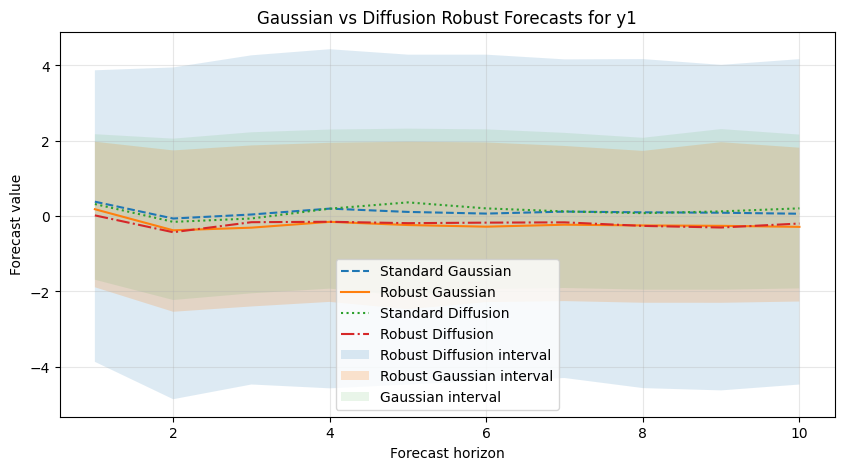

In [19]:
# -----------------------------------------------------------------------------
# Diffusion shock-path generator
# -----------------------------------------------------------------------------
@torch.no_grad()
def generate_diffusion_shock_path(h, model, x_dim, T_diff, device):
    """
    Generate an h-step shock path from the trained diffusion model
    on the original residual scale.
    """
    gen_std = sample_diffusion_shocks(
        model=model,
        n_samples=h,
        x_dim=x_dim,
        T_diff=T_diff,
        device=device
    ).cpu().numpy()

    gen_raw = gen_std * innovation_std_safe + innovation_mean
    return gen_raw


# -----------------------------------------------------------------------------
# Forecast draws using diffusion shocks
# -----------------------------------------------------------------------------
def simulate_diffusion_forecast_draws(
    n_draws,
    h,
    model,
    x_dim,
    T_diff,
    A_list,
    intercept,
    y_history,
    device,
    seed=123
):
    local_rng = np.random.default_rng(seed)
    draws = []

    for s in range(n_draws):
        _ = int(local_rng.integers(0, 10_000_000))  # reserved for reproducibility style

        shock_path = generate_diffusion_shock_path(
            h=h,
            model=model,
            x_dim=x_dim,
            T_diff=T_diff,
            device=device
        )

        y_path = simulate_var_forecast_with_shocks(
            A_list=A_list,
            intercept=intercept,
            y_history=y_history,
            shock_path=shock_path
        )
        draws.append(y_path)

    return np.array(draws)


def simulate_robust_diffusion_forecast_draws(
    n_draws,
    h,
    epsilon,
    direction,
    model,
    x_dim,
    T_diff,
    A_list,
    intercept,
    y_history,
    device,
    seed=123
):
    local_rng = np.random.default_rng(seed)
    draws = []

    for s in range(n_draws):
        _ = int(local_rng.integers(0, 10_000_000))

        shock_path = generate_diffusion_shock_path(
            h=h,
            model=model,
            x_dim=x_dim,
            T_diff=T_diff,
            device=device
        )

        shock_path_robust = perturb_shock_path(
            shock_path,
            epsilon=epsilon,
            direction=direction
        )

        y_path = simulate_var_forecast_with_shocks(
            A_list=A_list,
            intercept=intercept,
            y_history=y_history,
            shock_path=shock_path_robust
        )
        draws.append(y_path)

    return np.array(draws)


# -----------------------------------------------------------------------------
# Run diffusion forecast simulations
# -----------------------------------------------------------------------------
diffusion_forecast_draws = simulate_diffusion_forecast_draws(
    n_draws=n_mc_draws,
    h=h_forecast,
    model=diffusion_model,
    x_dim=x_dim,
    T_diff=T_diff,
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    device=DEVICE,
    seed=GLOBAL_SEED
)

robust_diffusion_draws = simulate_robust_diffusion_forecast_draws(
    n_draws=n_mc_draws,
    h=h_forecast,
    epsilon=epsilon,
    direction="down",
    model=diffusion_model,
    x_dim=x_dim,
    T_diff=T_diff,
    A_list=var_fit["A_hat_list"],
    intercept=var_fit["intercept"],
    y_history=y_history,
    device=DEVICE,
    seed=GLOBAL_SEED
)

diffusion_summary = summarize_forecast_draws(diffusion_forecast_draws, alpha=0.05)
robust_diffusion_summary = summarize_forecast_draws(robust_diffusion_draws, alpha=0.05)

print("=" * 80)
print("DIFFUSION FORECAST DRAWS GENERATED")
print("=" * 80)
print(f"Standard diffusion draws shape: {diffusion_forecast_draws.shape}")
print(f"Robust diffusion draws shape:   {robust_diffusion_draws.shape}")
print(f"Epsilon: {epsilon}")
print()

print("Diffusion forecast mean (first 5 horizons):")
display(pd.DataFrame(
    diffusion_summary["mean"][:5],
    columns=columns,
    index=np.arange(1, 6)
).round(4))

print("Robust diffusion forecast mean (first 5 horizons):")
display(pd.DataFrame(
    robust_diffusion_summary["mean"][:5],
    columns=columns,
    index=np.arange(1, 6)
).round(4))

plt.figure(figsize=(10, 5))

# -----------------------------------------------------------------------------
# Lines first (means)
# -----------------------------------------------------------------------------
plt.plot(future_index, gaussian_summary["mean"][:, 0],
         linestyle="--", label="Standard Gaussian")

plt.plot(future_index, robust_gaussian_summary["mean"][:, 0],
         linestyle="-", label="Robust Gaussian")

plt.plot(future_index, diffusion_summary["mean"][:, 0],
         linestyle=":", label="Standard Diffusion")

plt.plot(future_index, robust_diffusion_summary["mean"][:, 0],
         linestyle="-.", label="Robust Diffusion")

# -----------------------------------------------------------------------------
# Then intervals (fill_between)
# Order matters: draw wider intervals first (background)
# -----------------------------------------------------------------------------

# Robust Diffusion (widest → background)
plt.fill_between(
    future_index,
    robust_diffusion_summary["lower"][:, 0],
    robust_diffusion_summary["upper"][:, 0],
    alpha=0.15,
    label="Robust Diffusion interval"
)

# Robust Gaussian (on top)
plt.fill_between(
    future_index,
    robust_gaussian_summary["lower"][:, 0],
    robust_gaussian_summary["upper"][:, 0],
    alpha=0.20,
    label="Robust Gaussian interval"
)

# Optional: Standard Gaussian interval (lightest)
plt.fill_between(
    future_index,
    gaussian_summary["lower"][:, 0],
    gaussian_summary["upper"][:, 0],
    alpha=0.10,
    label="Gaussian interval"
)

# -----------------------------------------------------------------------------
# Final formatting
# -----------------------------------------------------------------------------
plt.title("Gaussian vs Diffusion Robust Forecasts for y1")
plt.xlabel("Forecast horizon")
plt.ylabel("Forecast value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [20]:
print(np.min(robust_diffusion_summary["lower"]))
print(np.max(robust_diffusion_summary["upper"]))

-4.862374612621903
4.430991059463099


## Sensitivity of Robust Forecasts to the Ambiguity Radius $\varepsilon$

We now study how forecast distributions change as the size of the ambiguity set increases.

Recall that the robustness parameter $\varepsilon$ controls how far the adversarial distribution can deviate from the reference innovation law:

$$
\mathcal{P}_\varepsilon = \{Q : W(Q, P_0) \le \varepsilon\}.
$$

As $\varepsilon$ increases:

- the model considers more extreme perturbations
- downside risk should increase
- predictive intervals should widen

We evaluate this effect by computing robust forecasts across a grid of $\varepsilon$ values and comparing:

- forecast means
- lower bounds (downside risk)
- interval widths

This provides a direct view of how sensitive the system is to distributional uncertainty.

In [21]:
# -----------------------------------------------------------------------------
# Epsilon sensitivity experiment
# -----------------------------------------------------------------------------
epsilon_grid = [0.0, 0.1, 0.3, 0.5]

results = {}

for eps in epsilon_grid:
    draws = simulate_robust_diffusion_forecast_draws(
        n_draws=n_mc_draws,
        h=h_forecast,
        epsilon=eps,
        direction="down",
        model=diffusion_model,
        x_dim=x_dim,
        T_diff=T_diff,
        A_list=var_fit["A_hat_list"],
        intercept=var_fit["intercept"],
        y_history=y_history,
        device=DEVICE,
        seed=GLOBAL_SEED
    )

    results[eps] = summarize_forecast_draws(draws, alpha=0.05)

print("=" * 80)
print("EPSILON SENSITIVITY COMPLETE")
print("=" * 80)
print("Epsilon grid:", epsilon_grid)

EPSILON SENSITIVITY COMPLETE
Epsilon grid: [0.0, 0.1, 0.3, 0.5]


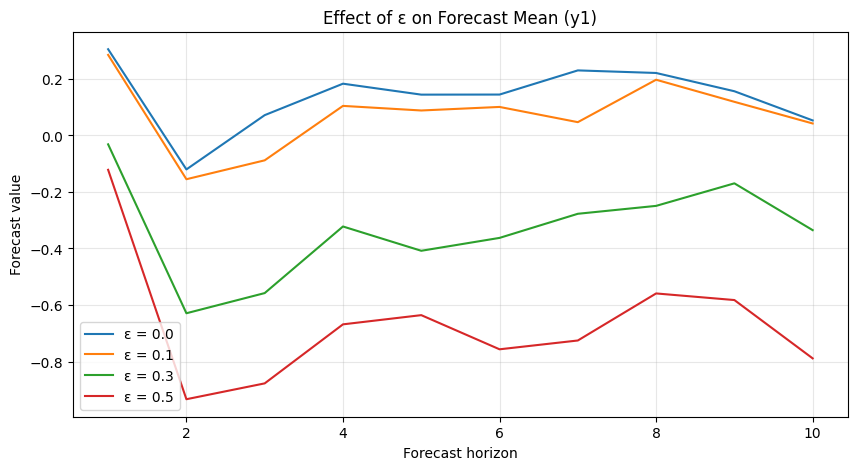

In [22]:
plt.figure(figsize=(10, 5))

for eps in epsilon_grid:
    plt.plot(
        future_index,
        results[eps]["mean"][:, 0],
        label=f"ε = {eps}"
    )

plt.title("Effect of ε on Forecast Mean (y1)")
plt.xlabel("Forecast horizon")
plt.ylabel("Forecast value")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

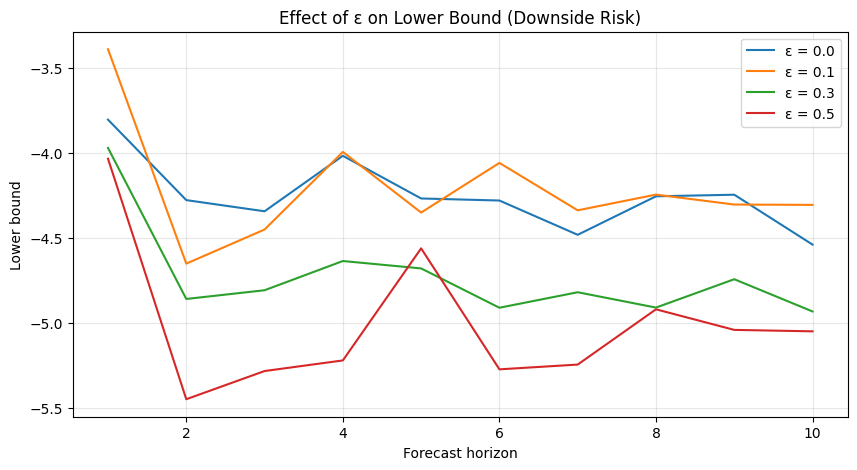

In [23]:
plt.figure(figsize=(10, 5))

for eps in epsilon_grid:
    plt.plot(
        future_index,
        results[eps]["lower"][:, 0],
        label=f"ε = {eps}"
    )

plt.title("Effect of ε on Lower Bound (Downside Risk)")
plt.xlabel("Forecast horizon")
plt.ylabel("Lower bound")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

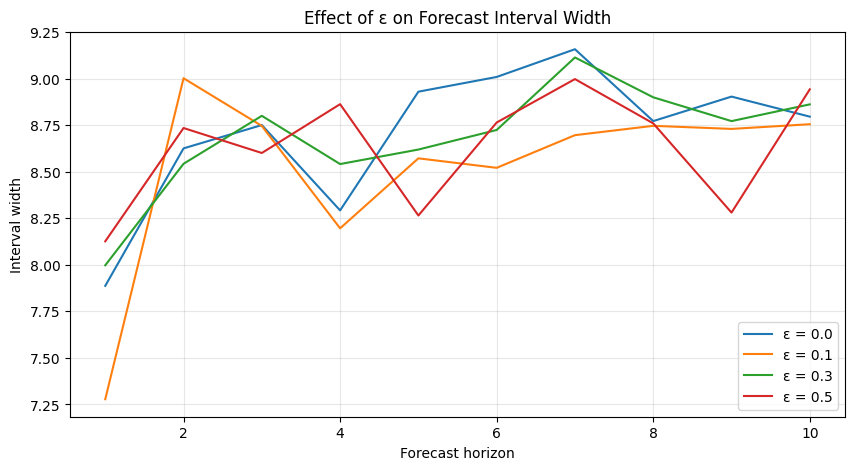

In [24]:
plt.figure(figsize=(10, 5))

for eps in epsilon_grid:
    width = results[eps]["upper"][:, 0] - results[eps]["lower"][:, 0]
    plt.plot(
        future_index,
        width,
        label=f"ε = {eps}"
    )

plt.title("Effect of ε on Forecast Interval Width")
plt.xlabel("Forecast horizon")
plt.ylabel("Interval width")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Summary of Forecast Outcomes at the Final Horizon

To compare the different forecast constructions more directly, we now summarize results at the final forecast horizon.

For each method, we record:

- forecast mean
- lower 95% bound
- upper 95% bound
- interval width

This gives a compact comparison of how standard and robust forecast distributions differ at a practically relevant horizon.

In [25]:
# -----------------------------------------------------------------------------
# Collect final-horizon summaries
# -----------------------------------------------------------------------------
final_h = h_forecast - 1  # zero-based index for last horizon

summary_rows = []

def add_summary_row(name, summary_obj, var_idx=0):
    lower = summary_obj["lower"][final_h, var_idx]
    mean = summary_obj["mean"][final_h, var_idx]
    upper = summary_obj["upper"][final_h, var_idx]
    width = upper - lower

    summary_rows.append({
        "model": name,
        "horizon": h_forecast,
        "variable": columns[var_idx],
        "mean": mean,
        "lower_95": lower,
        "upper_95": upper,
        "interval_width": width
    })

add_summary_row("Standard Gaussian", gaussian_summary, var_idx=0)
add_summary_row("Robust Gaussian", robust_gaussian_summary, var_idx=0)
add_summary_row("Standard Bootstrap", bootstrap_summary, var_idx=0)
add_summary_row("Standard Diffusion", diffusion_summary, var_idx=0)
add_summary_row("Robust Diffusion", robust_diffusion_summary, var_idx=0)

for eps in epsilon_grid:
    add_summary_row(f"Robust Diffusion (eps={eps})", results[eps], var_idx=0)

final_horizon_df = pd.DataFrame(summary_rows)

print("=" * 80)
print("FINAL-HORIZON FORECAST SUMMARY")
print("=" * 80)
display(final_horizon_df.round(4))

FINAL-HORIZON FORECAST SUMMARY


,model,horizon,variable,mean,lower_95,upper_95,interval_width
0,Standard Gaussian,10,y1,0.0625,-1.9198,2.1643,4.0842
1,Robust Gaussian,10,y1,-0.2856,-2.2680,1.8162,4.0842
2,Standard Bootstrap,10,y1,0.1040,-2.0337,2.1181,4.1518
3,Standard Diffusion,10,y1,0.2056,-4.1589,4.3795,8.5383
4,Robust Diffusion,10,y1,-0.1971,-4.4724,4.1676,8.6400
5,Robust Diffusion (eps=0.0),10,y1,0.0531,-4.5389,4.2575,8.7963
6,Robust Diffusion (eps=0.1),10,y1,0.0423,-4.3054,4.4502,8.7557
7,Robust Diffusion (eps=0.3),10,y1,-0.3352,-4.9319,3.9304,8.8623
8,Robust Diffusion (eps=0.5),10,y1,-0.7887,-5.0487,3.8944,8.9431


## Compare Robustness Across Variables at the Final Horizon

The previous table focused on $y_1$. We now summarize all forecast variables at the final horizon for the main methods:

- Standard Gaussian
- Robust Gaussian
- Standard Diffusion
- Robust Diffusion

This helps identify whether robustness affects all coordinates similarly or whether some variables are more sensitive to innovation ambiguity than others.

In [26]:
# -----------------------------------------------------------------------------
# Final-horizon summary across all variables
# -----------------------------------------------------------------------------
multi_rows = []

main_models = {
    "Standard Gaussian": gaussian_summary,
    "Robust Gaussian": robust_gaussian_summary,
    "Standard Diffusion": diffusion_summary,
    "Robust Diffusion": robust_diffusion_summary,
}

for model_name, summary_obj in main_models.items():
    for j, var_name in enumerate(columns):
        lower = summary_obj["lower"][final_h, j]
        mean = summary_obj["mean"][final_h, j]
        upper = summary_obj["upper"][final_h, j]
        width = upper - lower

        multi_rows.append({
            "model": model_name,
            "variable": var_name,
            "mean": mean,
            "lower_95": lower,
            "upper_95": upper,
            "interval_width": width
        })

multi_final_df = pd.DataFrame(multi_rows)

print("=" * 80)
print("FINAL-HORIZON SUMMARY ACROSS VARIABLES")
print("=" * 80)
display(multi_final_df.round(4))

FINAL-HORIZON SUMMARY ACROSS VARIABLES


,model,variable,mean,lower_95,upper_95,interval_width
0,Standard Gaussian,y1,0.0625,-1.9198,2.1643,4.0842
1,Standard Gaussian,y2,-0.0084,-1.8004,1.8343,3.6347
2,Standard Gaussian,y3,-0.0031,-1.8278,1.8067,3.6345
3,Robust Gaussian,y1,-0.2856,-2.2680,1.8162,4.0842
4,Robust Gaussian,y2,-0.3244,-2.1163,1.5183,3.6347
5,Robust Gaussian,y3,-0.3221,-2.1468,1.4877,3.6345
6,Standard Diffusion,y1,0.2056,-4.1589,4.3795,8.5383
7,Standard Diffusion,y2,0.2543,-3.6379,3.9335,7.5714
8,Standard Diffusion,y3,0.3024,-3.4963,3.8697,7.3660
9,Robust Diffusion,y1,-0.1971,-4.4724,4.1676,8.6400


## Visual Comparison of Final-Horizon Interval Widths

A useful way to compare robustness is to examine how much each method widens the predictive interval at the final horizon.

We plot final-horizon interval widths for the main competing methods.

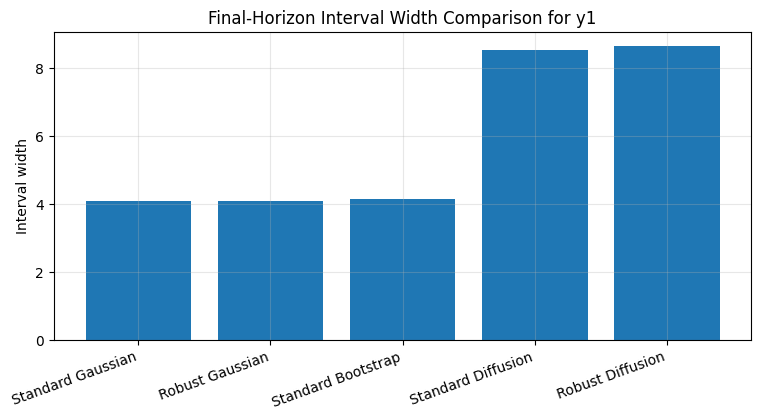

In [27]:
# -----------------------------------------------------------------------------
# Bar chart of final-horizon interval widths for y1
# -----------------------------------------------------------------------------
plot_df = final_horizon_df[
    final_horizon_df["model"].isin([
        "Standard Gaussian",
        "Robust Gaussian",
        "Standard Bootstrap",
        "Standard Diffusion",
        "Robust Diffusion"
    ])
].copy()

plt.figure(figsize=(9, 4))
plt.bar(plot_df["model"], plot_df["interval_width"])
plt.title("Final-Horizon Interval Width Comparison for y1")
plt.ylabel("Interval width")
plt.xticks(rotation=20, ha="right")
plt.grid(alpha=0.3, axis="y")
plt.show()

## Optional: Export DRO Forecasting Results

To make the robust forecasting notebook reproducible and reusable, we export the core forecast summaries and sensitivity results.

This includes:

- standard forecast summaries
- robust forecast summaries
- $\varepsilon$-sensitivity outputs
- final-horizon comparison tables

These outputs can be used later in write-ups, scripts, or real-data experiments.

In [28]:
import json
import pickle
from pathlib import Path
from datetime import datetime

# -----------------------------------------------------------------------------
# Logging helpers
# -----------------------------------------------------------------------------
def to_serializable_summary(summary_obj):
    return {
        "mean": np.asarray(summary_obj["mean"]).tolist(),
        "lower": np.asarray(summary_obj["lower"]).tolist(),
        "upper": np.asarray(summary_obj["upper"]).tolist(),
    }

def summarize_dro_experiment():
    out = {
        "timestamp_iso": datetime.now().isoformat(timespec="seconds"),
        "notebook": "05_dro_forecasting",
        "config": {
            "seed": GLOBAL_SEED,
            "forecast_horizon": int(h_forecast),
            "n_mc_draws": int(n_mc_draws),
            "epsilon": float(epsilon),
            "epsilon_grid": [float(x) for x in epsilon_grid],
            "diffusion_steps": int(T_diff),
            "device": str(DEVICE),
        },
        "standard_gaussian": to_serializable_summary(gaussian_summary),
        "robust_gaussian": to_serializable_summary(robust_gaussian_summary),
        "standard_bootstrap": to_serializable_summary(bootstrap_summary),
        "standard_diffusion": to_serializable_summary(diffusion_summary),
        "robust_diffusion": to_serializable_summary(robust_diffusion_summary),
        "epsilon_sensitivity": {
            str(eps): to_serializable_summary(results[eps]) for eps in epsilon_grid
        },
        "final_horizon_y1": final_horizon_df.to_dict(orient="records"),
        "final_horizon_all_vars": multi_final_df.to_dict(orient="records"),
    }
    return out

def save_dro_json(summary, save_dir="logs"):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = save_path / f"dro_forecasting_summary_{timestamp}.json"

    with open(filepath, "w") as f:
        json.dump(summary, f, indent=2)

    return filepath

def save_dro_pickle(save_dir="logs"):
    save_path = Path(save_dir)
    save_path.mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filepath = save_path / f"dro_forecasting_artifacts_{timestamp}.pkl"

    artifact = {
        "gaussian_summary": gaussian_summary,
        "robust_gaussian_summary": robust_gaussian_summary,
        "bootstrap_summary": bootstrap_summary,
        "diffusion_summary": diffusion_summary,
        "robust_diffusion_summary": robust_diffusion_summary,
        "epsilon_results": results,
        "final_horizon_df": final_horizon_df,
        "multi_final_df": multi_final_df,
    }

    with open(filepath, "wb") as f:
        pickle.dump(artifact, f)

    return filepath

dro_summary = summarize_dro_experiment()
dro_json_path = save_dro_json(dro_summary, save_dir="logs")
dro_pkl_path = save_dro_pickle(save_dir="logs")

print("=" * 80)
print("DRO FORECASTING LOGGING COMPLETE")
print("=" * 80)
print(f"JSON summary saved to:    {dro_json_path}")
print(f"Artifact bundle saved to: {dro_pkl_path}")
print()

print("Summary preview:")
print(json.dumps(dro_summary, indent=2)[:1500], "...")

DRO FORECASTING LOGGING COMPLETE
JSON summary saved to:    logs/dro_forecasting_summary_20260408_170935.json
Artifact bundle saved to: logs/dro_forecasting_artifacts_20260408_170935.pkl

Summary preview:
{
  "timestamp_iso": "2026-04-08T17:09:35",
  "notebook": "05_dro_forecasting",
  "config": {
    "seed": 123,
    "forecast_horizon": 10,
    "n_mc_draws": 1000,
    "epsilon": 0.2,
    "epsilon_grid": [
      0.0,
      0.1,
      0.3,
      0.5
    ],
    "diffusion_steps": 100,
    "device": "cpu"
  },
  "standard_gaussian": {
    "mean": [
      [
        0.3827329939901561,
        0.3714125519788075,
        0.09377956451532295
      ],
      [
        -0.06417016886334774,
        0.1252498164015259,
        0.16337735174914544
      ],
      [
        0.042486951225898184,
        0.05056887152592783,
        0.04128080527615815
      ],
      [
        0.19875737908836372,
        0.045098230144402465,
        -0.0007191573916862964
      ],
      [
        0.1108603016394941